<a href="https://colab.research.google.com/github/NBK-code/Reinforcement_Learning/blob/main/TN(N)_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from tqdm.notebook import tqdm
import gymnasium as gym

In [2]:
def epsilon_greedy(Q, state, epsilon, env):

    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [8]:
def n_step_q_learning(env, n=3, num_episodes=25000, alpha=0.01, gamma=0.99, epsilon=0.1):

    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_rewards = []

    for episode in range(num_episodes):

        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon, env)

        states = []
        actions = []
        rewards = []
        total_reward = 0
        done = False

        while not done:

            next_state, reward, terminal, truncated, _ = env.step(action)
            done = terminal or truncated

            next_action = epsilon_greedy(Q, next_state, epsilon, env)

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            total_reward += reward

            if len(rewards) >= n:

                G = sum([gamma**i * rewards[i] for i in range(n)])

                if not done:
                    G += gamma**n * np.max(Q[next_state])

                Q[states[0], actions[0]] += alpha * (G - Q[states[0], actions[0]])

                states.pop(0)
                actions.pop(0)
                rewards.pop(0)

            state, action = next_state, next_action

        episode_rewards.append(total_reward)

        while rewards:
            G = sum([gamma**i * rewards[i] for i in range(len(rewards))])
            Q[states[0], actions[0]] += alpha * (G - Q[states[0], actions[0]])
            states.pop(0)
            actions.pop(0)
            rewards.pop(0)

    return Q, episode_rewards

In [9]:
def test_policy(policy, env, num_episodes=100):

    total_rewards = []

    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action = policy[state]
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward

        total_rewards.append(ep_reward)

    success_rate = np.mean([1 if r > -100 else 0 for r in total_rewards])
    print(f"Success Rate: {success_rate * 100:.2f}%")
    return success_rate

In [10]:
Qs = []
rewards = []
ns = [1,3,5,7,9,11]
env = gym.make('CliffWalking-v1')

for n in ns:
    print(f"Training {n}-Step")
    Q, reward = n_step_q_learning(env, n)
    rewards.append(reward)
    policy = np.argmax(Q, axis=-1)
    test_policy(policy, env)

Training 1-Step
Success Rate: 100.00%
Training 3-Step
Success Rate: 100.00%
Training 5-Step
Success Rate: 100.00%
Training 7-Step
Success Rate: 100.00%
Training 9-Step
Success Rate: 100.00%
Training 11-Step
Success Rate: 100.00%


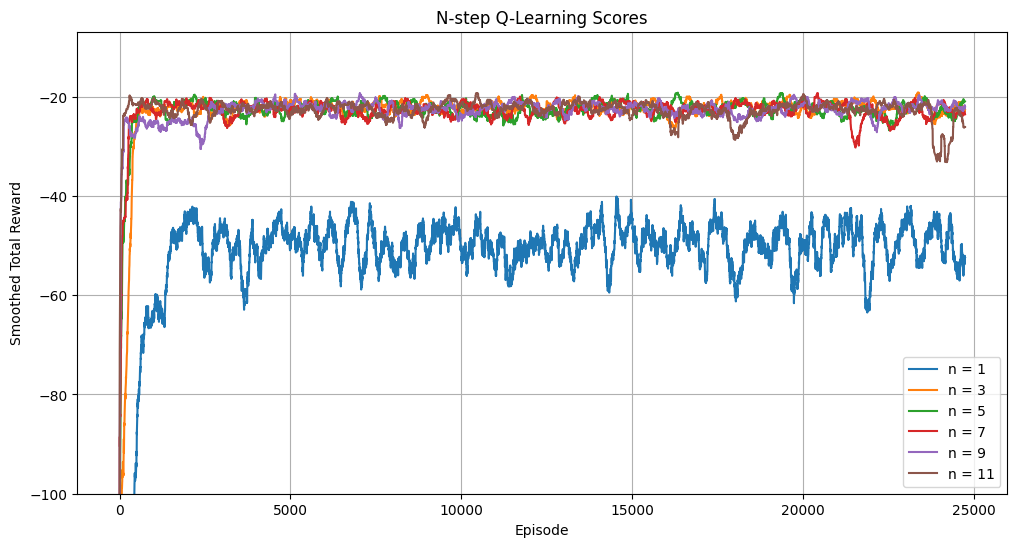

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for n, reward in zip(ns, rewards):
    smoothed = np.convolve(reward, np.ones(250)/250, mode='valid')
    plt.plot(smoothed, label=f"n = {n}")
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.ylim(-100)
plt.title("N-step Q-Learning Scores")
plt.legend()
plt.grid()
plt.show()